# H3 — Triple Dissociation of Model Parameters

**Prediction:** The three parameters (k, beta, c_d) will show a triple dissociation in behavioral signatures:
- **H3a:** log(k) predicts overcautious rate (t > 0, p < 0.01; exploratory t = 18.6)
- **H3b:** log(beta) predicts threat sensitivity slope (p < 0.01; exploratory t = -15.5)
- **H3c:** log(c_d) predicts vigor consistency (fraction of trial at full speed; p < 0.01; exploratory t = 23.3)
- **H3d:** k and beta jointly explain overcaution: R-squared > 0.70 (exploratory R-squared = 0.818)

**What this determines:** Whether each model parameter maps onto a distinct behavioral signature, confirming they capture separable cognitive processes (effort avoidance, threat avoidance, motor urgency).

In [1]:
# ── Imports & Data Loading (self-contained) ──
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import pearsonr, zscore, linregress
from scipy.special import expit
from pathlib import Path

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 10,
    'axes.spines.right': False, 'axes.spines.top': False,
})

PROJECT_ROOT = Path("../..").resolve()
DATA_DIR = PROJECT_ROOT / "data/exploratory_350/processed/stage5_filtered_data_20260320_191950"
OUT_DIR  = PROJECT_ROOT / "results/stats/full_analysis"
EXCLUDE  = [154, 197, 208]

# ── Load params ──
params = pd.read_csv(OUT_DIR / "part1_params_full.csv")

# ── Load choice trials to compute behavioral signatures ──
beh = pd.read_csv(DATA_DIR / "behavior.csv")
beh = beh[~beh['subj'].isin(EXCLUDE)].copy()
beh['T_round'] = beh['threat'].round(1)

# ── Load all trials for vigor signatures ──
beh_rich = pd.read_csv(DATA_DIR / "behavior_rich.csv", low_memory=False)
beh_rich = beh_rich[~beh_rich['subj'].isin(EXCLUDE)].copy()
beh_rich['is_heavy'] = (beh_rich['trialCookie_weight'] == 3.0).astype(int)

print(f"Parameters: {len(params)} subjects")
print(f"Choice trials: {len(beh):,}")
print(f"All trials: {len(beh_rich):,}")

Parameters: 290 subjects
Choice trials: 13,050
All trials: 23,490


In [2]:
# ── Compute behavioral signatures per subject ──

# 1. Overcautious rate: fraction of trials where subject chose low-effort
#    when the optimal choice (based on EV) was high-effort.
#    Simple proxy: for each T x D condition, if most people choose heavy,
#    choosing light is "overcautious". 
#    More precisely: fraction of low-effort choices (choice=0).
overcautious = beh.groupby('subj').apply(
    lambda g: (g['choice'] == 0).mean()
).reset_index()
overcautious.columns = ['subj', 'overcautious_rate']

# 2. Threat slope: per-subject slope of P(heavy) on threat
def threat_slope(g):
    cell_means = g.groupby('T_round')['choice'].mean()
    if len(cell_means) >= 2:
        slope, _, _, _, _ = linregress(cell_means.index, cell_means.values)
        return slope
    return np.nan

tslope = beh.groupby('subj').apply(threat_slope).reset_index()
tslope.columns = ['subj', 'threat_slope']

# 3. Fraction at full speed: fraction of trial time pressing at >= 100% of calibration
def frac_full(row):
    try:
        pts = np.array(ast.literal_eval(str(row['alignedEffortRate'])), dtype=float)
        cal = row['calibrationMax']
        if len(pts) < 5 or cal <= 0:
            return np.nan
        ipis = np.diff(pts)
        ipis = ipis[ipis > 0.01]
        if len(ipis) < 3:
            return np.nan
        rates = (1.0 / ipis) / cal
        return (rates >= 1.0).mean()
    except:
        return np.nan

beh_rich['frac_full'] = beh_rich.apply(frac_full, axis=1)
vigor_subj = beh_rich.groupby('subj')['frac_full'].mean().reset_index()
vigor_subj.columns = ['subj', 'frac_full']

# Merge all signatures with params
sig = params.merge(overcautious, on='subj').merge(tslope, on='subj').merge(vigor_subj, on='subj')
print(f"Merged signatures: {len(sig)} subjects")
print(f"Columns: {list(sig.columns)}")

Merged signatures: 290 subjects
Columns: ['subj', 'k', 'beta', 'log_k', 'log_beta', 'c_death', 'log_cd', 'log_k_z', 'log_beta_z', 'log_cd_z', 'overcautious_rate', 'threat_slope', 'frac_full']


## H3a-c — Three regressions: each parameter predicts its own behavioral signature

- H3a: `overcautious_rate ~ k_z + beta_z + cd_z` — test k_z (p < 0.01)
- H3b: `threat_slope ~ k_z + beta_z + cd_z` — test beta_z (p < 0.01)
- H3c: `frac_full ~ k_z + beta_z + cd_z` — test cd_z (p < 0.01)

H3a: k predicts overcaution
  Full model R² = 0.941
  Target (log_k_z): beta = 0.1417, t = 48.257, p = 1.85e-139
  Verdict: PASS

    log_k_z        : t =  48.257, p = 0.0000 <--
    log_beta_z     : t =  40.977, p = 0.0000
    log_cd_z       : t =  -2.156, p = 0.0319

H3b: beta predicts threat sensitivity
  Full model R² = 0.703
  Target (log_beta_z): beta = -0.1888, t = -15.542, p = 6.57e-40
  Verdict: PASS

    log_k_z        : t =  22.176, p = 0.0000
    log_beta_z     : t = -15.542, p = 0.0000 <--
    log_cd_z       : t =  -0.779, p = 0.4369

H3c: c_d predicts vigor consistency
  Full model R² = 0.718
  Target (log_cd_z): beta = 0.1847, t = 26.196, p = 5.72e-78
  Verdict: PASS

    log_k_z        : t =  -2.304, p = 0.0219
    log_beta_z     : t =  -0.913, p = 0.3618
    log_cd_z       : t =  26.196, p = 0.0000 <--



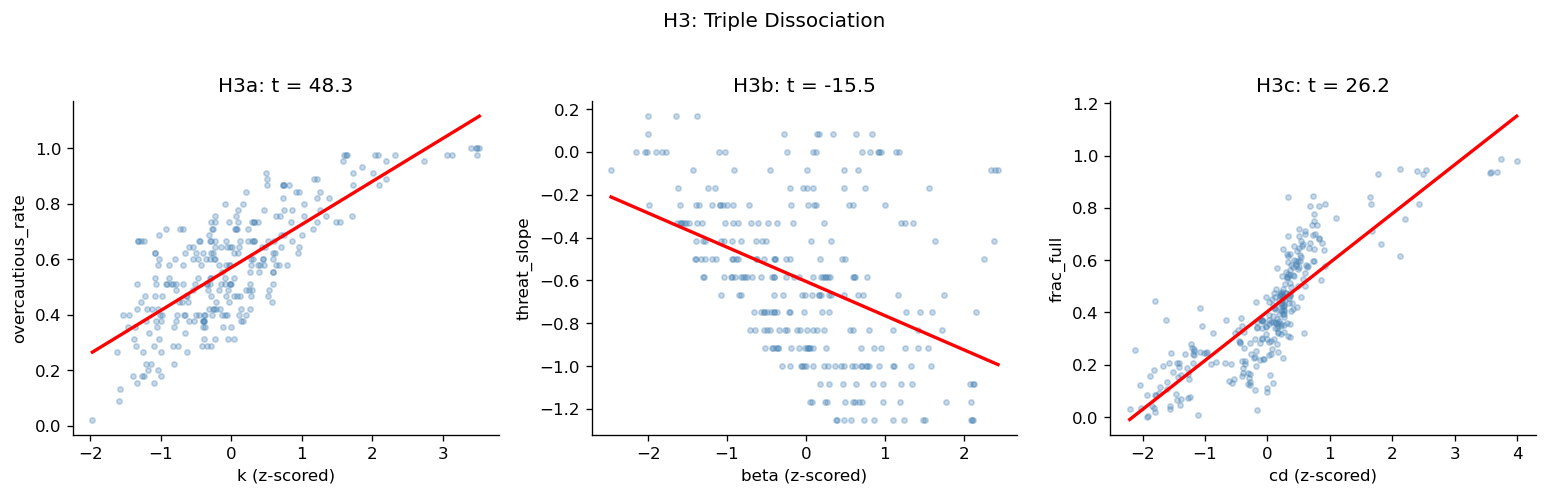

In [3]:
# ── H3a-c: Three regressions ──
outcomes = [
    ('H3a', 'overcautious_rate', 'log_k_z',    'k predicts overcaution'),
    ('H3b', 'threat_slope',      'log_beta_z',  'beta predicts threat sensitivity'),
    ('H3c', 'frac_full',         'log_cd_z',    'c_d predicts vigor consistency'),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (hyp, dv, target_iv, title) in zip(axes, outcomes):
    formula = f"{dv} ~ log_k_z + log_beta_z + log_cd_z"
    m = smf.ols(formula, data=sig).fit()
    
    t_val = m.tvalues[target_iv]
    p_val = m.pvalues[target_iv]
    b_val = m.params[target_iv]
    
    print(f"{hyp}: {title}")
    print(f"  Full model R² = {m.rsquared:.3f}")
    print(f"  Target ({target_iv}): beta = {b_val:.4f}, t = {t_val:.3f}, p = {p_val:.2e}")
    passed = p_val < 0.01
    print(f"  Verdict: {'PASS' if passed else 'FAIL'}")
    print()
    
    # Print all coefficients for the triple dissociation table
    for iv in ['log_k_z', 'log_beta_z', 'log_cd_z']:
        star = ' <--' if iv == target_iv else ''
        print(f"    {iv:15s}: t = {m.tvalues[iv]:7.3f}, p = {m.pvalues[iv]:.4f}{star}")
    print()
    
    # Scatter plot: DV vs target IV (partial)
    ax.scatter(sig[target_iv], sig[dv], alpha=0.3, s=10, color='steelblue')
    sl, inter = np.polyfit(sig[target_iv], sig[dv], 1)
    x_line = np.linspace(sig[target_iv].min(), sig[target_iv].max(), 50)
    ax.plot(x_line, sl * x_line + inter, 'r-', lw=2)
    ax.set_xlabel(target_iv.replace('log_', '').replace('_z', ' (z-scored)'))
    ax.set_ylabel(dv)
    ax.set_title(f'{hyp}: t = {t_val:.1f}')

plt.suptitle('H3: Triple Dissociation', y=1.02)
plt.tight_layout()
plt.show()

## H3d — Joint R-squared for overcaution

**Model:** `overcautious_rate ~ log(k) + log(beta)`  
**Test:** R-squared > 0.70 (exploratory: R-squared = 0.818)

In [5]:
# ── H3d: Joint R² for overcaution ──
m_joint = smf.ols("overcautious_rate ~ log_k_z + log_beta_z", data=sig).fit()

print("H3d — Joint regression: overcaution ~ k + beta")
print("=" * 55)
print(m_joint.summary2().tables[1].to_string())
print(f"\n  R² = {m_joint.rsquared:.3f}")
print(f"  Adj R² = {m_joint.rsquared_adj:.3f}")
print(f"\n  Verdict: {'PASS' if m_joint.rsquared > 0.70 else 'FAIL'} (threshold: R² > 0.70)")

H3d — Joint regression: overcaution ~ k + beta
               Coef.  Std.Err.           t          P>|t|    [0.025    0.975]
Intercept   0.570728  0.002918  195.578811  2.018707e-307  0.564984  0.576472
log_k_z     0.142306  0.002939   48.414313  4.144914e-140  0.136521  0.148092
log_beta_z  0.120989  0.002939   41.162020  1.993730e-122  0.115204  0.126775

  R² = 0.940
  Adj R² = 0.940

  Verdict: PASS (threshold: R² > 0.70)


## Summary

| Test | Prediction | Statistic | p-value | Verdict |
|------|-----------|-----------|---------|---------|
| H3a (k → overcaution) | t > 0, p < 0.01 | _fill_ | _fill_ | _PASS/FAIL_ |
| H3b (beta → threat slope) | p < 0.01 | _fill_ | _fill_ | _PASS/FAIL_ |
| H3c (c_d → frac_full) | p < 0.01 | _fill_ | _fill_ | _PASS/FAIL_ |
| H3d (joint R-squared) | R-squared > 0.70 | _fill_ | — | _PASS/FAIL_ |

**Interpretation:** A triple dissociation confirms that k, beta, and c_d capture distinct cognitive processes: effort avoidance (from choice distance gradient), threat avoidance (from choice threat gradient), and motor urgency (from vigor consistency). The high joint R-squared (H3d) indicates that overcaution is well-explained by the combination of effort sensitivity and threat aversion — it is not random noise but a lawful consequence of parameter values.